# PSyle Checker

## Load and Explore Dataset

In [1]:
# import pandas as pd
# import json

# ---------------------------------------------------------
# 1. Load OLD CSV dataset
# ---------------------------------------------------------
# df_old = pd.read_csv("../data/image_pairs_labels.csv")
# # normalize backslashes to forward slashes, strip spaces
# df_old['img1_path'] = df_old['img1_path'].astype(str).str.strip().str.replace('\\', '/', regex=False)
# df_old['img2_path'] = df_old['img2_path'].astype(str).str.strip().str.replace('\\', '/', regex=False)

# # now replace the prefix (plain string, not regex)
# old_prefix = 'C:/Users/maria/Downloads/dataset/'
# new_prefix = '../data/dataset/'

# df_old['img1_path'] = df_old['img1_path'].str.replace(old_prefix, new_prefix, regex=False)
# df_old['img2_path'] = df_old['img2_path'].str.replace(old_prefix, new_prefix, regex=False)

# # ---------------------------------------------------------
# # 2. Load NEW JSON dataset
# # ---------------------------------------------------------
# file_path = "../data/dataset_new/data_complicated/dataset_metadata.json"

# with open(file_path, 'r') as file:
#     data = json.load(file)

# data_df = pd.DataFrame(data['dataset'])

# # Fix image paths
# data_df['img1_path'] = data_df['img1'].str.replace(
#     r'^data_complicated\\',
#     r'../data/dataset_new/data_complicated/',
#     regex=True
# )
# data_df['img2_path'] = data_df['img2'].str.replace(
#     r'^data_complicated\\',
#     r'../data/dataset_new/data_complicated/',
#     regex=True
# )

# # Drop unnecessary columns
# data_df = data_df.drop(["pair_id", "style_match", "font_match", "img1", "img2"], axis=1)
# # ---------------------------------------------------------
# # 3. MERGE df_old and df → df_data
# # ---------------------------------------------------------

# # Perform the merge (inner join = only matching rows)
# df = pd.concat([df_old, data_df], axis=0, ignore_index=True)
# df = data_df
# # Shuffle 3× (your choice)
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# df['original_index'] = df.index
# df =df.head(6000)

# # ---------------------------------------------------------
# # 4. DONE — df_data is your merged dataset
# # ---------------------------------------------------------
# print("Merged DataFrame shape:", df.shape)
# print(df.head())


Merged DataFrame shape: (3000, 5)
   style_label  font_label                                          img1_path  \
0            0           1  ../data/dataset_new/data_complicated/img1_1801...   
1            1           1  ../data/dataset_new/data_complicated/img1_1190...   
2            0           1  ../data/dataset_new/data_complicated/img1_1817...   
3            0           0  ../data/dataset_new/data_complicated/img1_251.png   
4            0           1  ../data/dataset_new/data_complicated/img1_2505...   

                                           img2_path  original_index  
0  ../data/dataset_new/data_complicated/img2_1801...               0  
1  ../data/dataset_new/data_complicated/img2_1190...               1  
2  ../data/dataset_new/data_complicated/img2_1817...               2  
3  ../data/dataset_new/data_complicated/img2_251.png               3  
4  ../data/dataset_new/data_complicated/img2_2505...               4  


In [ ]:
# df_training_path ="../data/dataset_new/tainning_dataset2.csv"
# df.to_csv(df_training_path, index= False)

In [5]:
import pandas as pd
file_path ="../data/dataset_new/tainning_dataset.csv"
df = pd.read_csv(file_path)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Assuming the DataFrame `df` has the same structure
image_pairs = list(zip(df['img1_path'], df['img2_path']))
style_labels = df['style_label'].tolist()
font_labels = df['font_label'].tolist()

# Now `image_pairs`, `style_labels`, and `font_labels` are reconstructed

df['original_index'] = df.index

In [6]:
# Assuming the DataFrame `df` has the same structure

image_pairs = list(zip(df['img1_path'], df['img2_path']))
style_labels = df['style_label'].tolist()
font_labels = df['font_label'].tolist()


## Model training single lable output

In [7]:
import numpy as np
import gc
import time
from PIL import Image

from sklearn.model_selection import StratifiedKFold, train_test_split

from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Concatenate, Activation, Lambda
)
from tensorflow.keras.utils import Sequence
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K



# ---------------------------------------------------------
#  LAZY LOADING GENERATOR (loads from disk only when needed)
# ---------------------------------------------------------
class LazyImageGenerator(Sequence):
    def __init__(self, image_pairs, labels, batch_size=16, shuffle=True):
        self.image_pairs = image_pairs
        self.labels = np.array(labels, dtype=np.float32)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.labels))
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = img.resize((224, 224))
        img = np.array(img, dtype=np.float32) / 255.0
        return img

    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size : (index + 1) * self.batch_size]

        batch_1 = []
        batch_2 = []
        batch_labels = self.labels[batch_idx]

        for i in batch_idx:
            p1, p2 = self.image_pairs[i]
            batch_1.append(self._load_image(p1))
            batch_2.append(self._load_image(p2))

        return [np.array(batch_1), np.array(batch_2)], batch_labels



# ---------------------------------------------------------
#  Shared CNN Encoder
# ---------------------------------------------------------
def create_cnn_encoder(input_shape):
    inp = Input(shape=input_shape)

    def block(x, filters):
        x = Conv2D(filters, (3, 3), padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = MaxPooling2D((2, 2))(x)
        return x

    x = block(inp, 32)
    x = block(x, 64)
    x = block(x, 128)
    x = block(x, 256)

    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation=None, kernel_regularizer=regularizers.l2(1e-4))(x)
    emb = Lambda(lambda t: K.l2_normalize(t, axis=1))(x)

    return Model(inp, emb, name="shared_encoder")



# ---------------------------------------------------------
#  Dual-image Similarity Model
# ---------------------------------------------------------
def create_dual_encoder_model(input_shape):
    encoder = create_cnn_encoder(input_shape)

    input_1 = Input(shape=input_shape)
    input_2 = Input(shape=input_shape)

    p1 = encoder(input_1)
    p2 = encoder(input_2)

    diff = Lambda(lambda t: (t[0] - t[1]) ** 2)([p1, p2])
    prod = Lambda(lambda t: t[0] * t[1])([p1, p2])

    combined = Concatenate()([p1, p2, diff, prod])

    x = Dense(128, activation='relu')(combined)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[input_1, input_2], outputs=output)
    model.compile(optimizer=Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model



# ---------------------------------------------------------
#  TRAIN / TEST SPLIT
# ---------------------------------------------------------
X = np.arange(len(style_labels))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    style_labels,
    test_size=0.2,
    random_state=42,
    stratify=style_labels
)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)



# ---------------------------------------------------------
#  K-FOLDS TRAINING
# ---------------------------------------------------------
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f"\n--- Training fold {fold + 1} ---")

    K.clear_session()
    gc.collect()

    model = create_dual_encoder_model(input_shape=(224, 224, 3))

    # Lazy loading datasets
    train_pairs = [image_pairs[i] for i in X_train[train_idx]]
    val_pairs   = [image_pairs[i] for i in X_train[val_idx]]

    train_gen = LazyImageGenerator(train_pairs, y_train[train_idx], batch_size=16, shuffle=True)
    val_gen   = LazyImageGenerator(val_pairs, y_train[val_idx], batch_size=16, shuffle=False)

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=100,
        callbacks=[reduce_lr, early_stopping],
        verbose=1
    )

    print(f"--- Fold {fold + 1} completed ---")

end_time = time.time()
print("Total training time:", round(end_time - start_time, 2), "seconds")



# ---------------------------------------------------------
#  FINAL TEST EVALUATION
# ---------------------------------------------------------
test_pairs = [image_pairs[i] for i in X_test]
test_gen = LazyImageGenerator(test_pairs, y_test, batch_size=16, shuffle=False)

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print("\nTest accuracy:", round(test_acc, 4))



--- Training fold 1 ---
Epoch 1/100
240/240 [==============================] - 18s 69ms/step - loss: 0.7256 - accuracy: 0.5576 - val_loss: 0.6789 - val_accuracy: 0.5740 - lr: 3.0000e-04
Epoch 2/100
240/240 [==============================] - 16s 68ms/step - loss: 0.6625 - accuracy: 0.6021 - val_loss: 0.6163 - val_accuracy: 0.6240 - lr: 3.0000e-04
Epoch 3/100
240/240 [==============================] - 16s 68ms/step - loss: 0.6281 - accuracy: 0.6281 - val_loss: 0.5997 - val_accuracy: 0.6719 - lr: 3.0000e-04
Epoch 4/100
240/240 [==============================] - 16s 67ms/step - loss: 0.5938 - accuracy: 0.6706 - val_loss: 0.7098 - val_accuracy: 0.6500 - lr: 3.0000e-04
Epoch 5/100
240/240 [==============================] - 16s 68ms/step - loss: 0.5710 - accuracy: 0.6893 - val_loss: 0.5411 - val_accuracy: 0.7260 - lr: 3.0000e-04
Epoch 6/100
240/240 [==============================] - 16s 68ms/step - loss: 0.5593 - accuracy: 0.6935 - val_loss: 0.5122 - val_accuracy: 0.7542 - lr: 3.0000e-04
Epo

In [18]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 shared_encoder (Functional)    (None, 128)          423232      ['input_2[0][0]',                
                                                                  'input_3[0][0]']            

In [ ]:
import numpy as np

def check_array(arr, name):
    print(f"\nChecking: {name}")
    print("- dtype:", arr.dtype)
    print("- shape:", arr.shape)
    if arr.dtype == object:
        print("❌ ERROR: array dtype is OBJECT → contains invalid elements!")
        return True

    # Loop through images
    for i in range(len(arr)):
        img = arr[i]

        # None or wrong type
        if img is None:
            print(f"❌ {name}[{i}] is None")
            return True
        if not isinstance(img, np.ndarray):
            print(f"❌ {name}[{i}] is not numpy array → {type(img)}")
            return True

        # Wrong shape
        if img.shape != (224, 224, 3):
            print(f"❌ {name}[{i}] wrong shape: {img.shape}")
            return True

        # Wrong dtype
        if img.dtype not in [np.uint8, np.float32]:
            print(f"❌ {name}[{i}] wrong dtype: {img.dtype}")
            return True

        # NaN values
        if np.isnan(img).any():
            print(f"❌ {name}[{i}] contains NaN")
            return True

    print(f"✔ {name} looks OK")
    return False


# ----------------------------------------------------------
# RUN CHECKS
# ----------------------------------------------------------

bad1 = check_array(X_train_fold_1, "X_train_fold_1")
bad2 = check_array(X_train_fold_2, "X_train_fold_2")
bad3 = check_array(X_val_fold_1, "X_val_fold_1")
bad4 = check_array(X_val_fold_2, "X_val_fold_2")

if not (bad1 or bad2 or bad3 or bad4):
    print("\n🎉 ALL ARRAYS CLEAN — the problem is somewhere else (model, GPU, memory).")


In [ ]:
#Testing with real images

In [21]:
import os
import pandas as pd

base_path = "../data/test_dataset/different_style"

rows = []

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)
    if os.path.isdir(folder_path):
        image_files = sorted([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        # Expect exactly two images per folder
        if len(image_files) != 2:
            print(f"Warning: different_style folder {folder_name} does not contain exactly 2 images.")
            continue

        img1_path = os.path.join(folder_path, image_files[0])
        img2_path = os.path.join(folder_path, image_files[1])

        rows.append({
            "style_label": 0,
            "img1_path": img1_path,
            "img2_path": img2_path
        })
        
base_path = "../data/test_dataset/same_style"

for folder_name in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder_name)
    if os.path.isdir(folder_path):
        image_files = sorted([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        # Expect exactly two images per folder
        if len(image_files) != 2:
            print(f"Warning: same_style folder {folder_name} does not contain exactly 2 images.")
            continue

        img1_path = os.path.join(folder_path, image_files[0])
        img2_path = os.path.join(folder_path, image_files[1])

        rows.append({
            "style_label": 1,
            "img1_path": img1_path,
            "img2_path": img2_path
        })
test_df = pd.DataFrame(rows)
# Assuming the DataFrame `df` has the same structure
image_pairs_test = list(zip(test_df['img1_path'], test_df['img2_path']))
style_labels_test = test_df['style_label'].tolist()

# Convert to numpy arrays
image_pairs_test = np.array(image_pairs_test)
style_labels_test = np.array(style_labels_test)

# Function to load and preprocess an image
def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((224, 224)).convert("RGB")  # Resize to match input shape
    img = np.array(img) / 255.0  # Normalize pixel values
    return img

# Load and preprocess the images
images_1_test= np.array([load_and_preprocess_image(path) for path in image_pairs_test[:, 0]])
images_2_test = np.array([load_and_preprocess_image(path) for path in image_pairs_test[:, 1]])


In [22]:
test_loss, test_accuracy = model.evaluate([images_1_test, images_2_test], style_labels_test, verbose=0)
print(f"\nTest accuracy: {test_accuracy:.4f}")


Test accuracy: 0.8750


1/1 [==============================] - 0s 38ms/step
Wrong predictions at indices: [19 25 28 30]

❌ Wrong prediction at index: 19
  True label:      1
  Predicted label: 0
  img1: ../data/test_dataset/same_style\11\147.PNG
  img2: ../data/test_dataset/same_style\11\148.PNG

❌ Wrong prediction at index: 25
  True label:      1
  Predicted label: 0
  img1: ../data/test_dataset/same_style\3\text,picture,boring3.png
  img2: ../data/test_dataset/same_style\3\text,picture2.png

❌ Wrong prediction at index: 28
  True label:      1
  Predicted label: 0
  img1: ../data/test_dataset/same_style\6\Capture1.PNG
  img2: ../data/test_dataset/same_style\6\Capture3.PNG

❌ Wrong prediction at index: 30
  True label:      1
  Predicted label: 0
  img1: ../data/test_dataset/same_style\8\105.png
  img2: ../data/test_dataset/same_style\8\107.png
Confusion matrix:


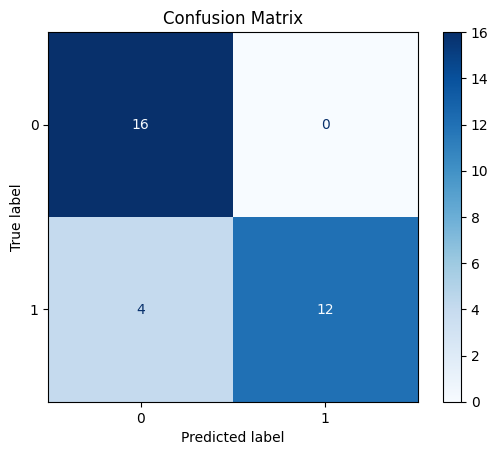

In [23]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds = model.predict([images_1_test, images_2_test])
preds = (preds > 0.5).astype(int).flatten()  # convert to binary 0/1
wrong_idx = np.where(preds != style_labels_test)[0]

print("Wrong predictions at indices:", wrong_idx)
for i in wrong_idx:
    print(f"\n❌ Wrong prediction at index: {i}")
    print(f"  True label:      {style_labels_test[i]}")
    print(f"  Predicted label: {preds[i]}")
    print(f"  img1: {image_pairs_test[i][0]}")
    print(f"  img2: {image_pairs_test[i][1]}")
    
print("Confusion matrix:")
cm = confusion_matrix(style_labels_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [11]:
import os

def save_all_models(model, model_name,category, save_dir="saved_models"):
    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, model_name)
    model.save(model_path)
    print(f"Saved model for category '{category}' at '{model_path}'")
        
save_dir="../exported_model"
model_name = "pstylechecker_stylemodel_2"
category= "style_coherence"
save_all_models(model,model_name, category, save_dir)


INFO:tensorflow:Assets written to: ../exported_model\pstylechecker_stylemodel_2\assets


INFO:tensorflow:Assets written to: ../exported_model\pstylechecker_stylemodel_2\assets


Saved model for category 'style_coherence' at '../exported_model\pstylechecker_stylemodel_2'


In [ ]:
## Evaluationm

75/75 [==============================] - 3s 35ms/step
Style Output - Accuracy: 0.86, Precision: 0.79, Recall: 0.98, F1 Score: 0.88
Jaccard Similarity:  0.7780713342140027
Cohen's Kappa:  0.72
ROC AUC:  0.8964833333333333


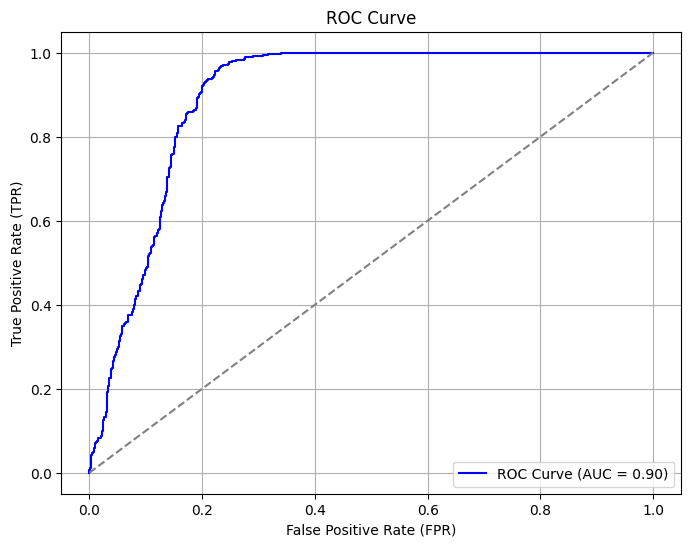

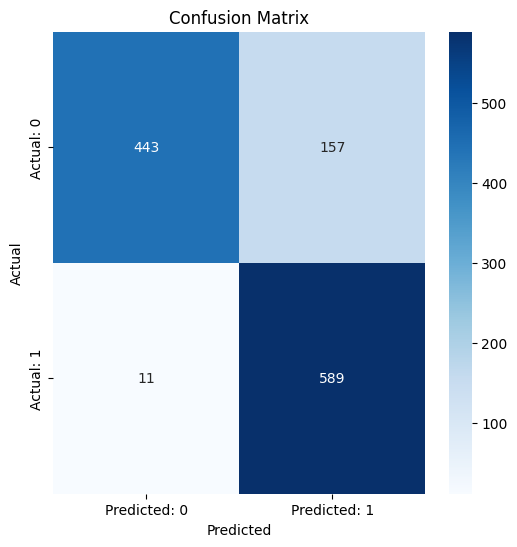

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, cohen_kappa_score, roc_auc_score, roc_curve, confusion_matrix
import json
# Predict on the validation set
style_pred_val = model.predict(test_gen)

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val_binary = (style_pred_val > 0.5).astype(int)

# Identify False Positives
false_positive_paths = [
    X_test[i] for i, (true, pred) in enumerate(zip(y_test, style_pred_val_binary)) if true == 0 and pred == 1
]


# Analyze the corresponding attributes
# for idx in false_positive_indices:
#     attributes_img1 = json.loads(df.loc[idx, 'attributes_img1'])
#     attributes_img2 = json.loads(df.loc[idx, 'attributes_img2'])
#     print(f"False Positive Pair {idx}:")
#     print(f"Attributes Image 1: {attributes_img1}")
#     print(f"Attributes Image 2: {attributes_img2}")


# Calculate additional metrics using sklearn
style_accuracy = accuracy_score(y_test, style_pred_val_binary)
style_precision = precision_score(y_test, style_pred_val_binary)
style_recall = recall_score(y_test, style_pred_val_binary)
style_f1 = f1_score(y_test, style_pred_val_binary)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")

# Compute Jaccard similarity
jaccard = jaccard_score(y_test, style_pred_val_binary)
print("Jaccard Similarity: ", jaccard)

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_test, style_pred_val_binary)
print("Cohen's Kappa: ", kappa)

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, style_pred_val)
print("ROC AUC: ", roc_auc)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, style_pred_val)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, style_pred_val_binary)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted: 0", "Predicted: 1"], yticklabels=["Actual: 0", "Actual: 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

